# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 24     |  |
| :-------------|:-------------|
| Job Kruisdijk| 6278108 |
| Thibo Alders| 6581390 |
| Elisabeth Mijnders|6580971|

| Planning Groep: 24     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: sanity check | 11:30 |
| Mijlpaal 2: ideeën voor sensor af | 12:00 |
| Mijlpaal 3: criteria af | 12:15 |
| Mijlpaal 4: keuze sensor en toepassing | 12:45 |
| Pauze 1| 1 uur |
| Mijlpaal 5: opstelling gebouwd | 14:15 |
| Mijlpaal 6: code geschreven | 14:45 |
| Mijlpaal 7: Eerste kalibratie meting gedaan| 15:15 |
| Pauze 2| 30 min |
| Mijlpaal 8: conclusie af | 16:15 |
| Mijlpaal 8: opruimen | 16:45 |

## *Opdracht 1*: Foto van alle schetsen.
Schetsen Thibo:

<div style="display: flex; gap: 20px;">
    <img src="Thibo-Lichtmeter-krachtmeter.png" width="300">
    <img src="Thibo-Thermometer.png" width="300">
</div>

schetsen Job:
<div style="display: flex; gap: 20px;">
    <img src="Job-krachtmeter-lichtmeter.png" width="300">
    <img src="Job-Thermometer-krachtmeter.jpeg" width="300">
</div>

schetsen Elisabeth:
<div style="display: flex; gap: 20px;">
    <img src="Elisabeth-meters.png" width="300">
</div>

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Thermometer | is mijn eten te warm | moet kunnen meten tussen 40 en 80 graden C, met een onzekerheid van 5 graden C, moet een melding geven bij een temperatuur van meer dan 60 graden C. |
|Thermometer | oververhit een auto | moet aan kunnen geven dat iets warmer is dan 100 - 140 graden C, met een onzekerheid van 5 graden C, moet een melding geven bij een temperatuur van meer dan 120 graden C. |
|Thermometer | warmte schakelaar | moet verschil kunnen meten tussen 23 en 30 graden C, met een onzekerheid van 1 graden C, moet een stroomlaten lopen.|
|Lichtmeter | zonne meter voor planten | Criteria omschrijving |
|Lichtmeter | kan ik sterre zien | Criteria omschrijving  |
|Lichtmeter | licht dat aan gaat bij donker | kan het verschil meten tussen 0 en 1300 lux, met een onzekerheid van 50 lux, doet een lamp als er een kleinere lux is dan 1000 |
|krachtmeter | weegschaal | Criteria omschrijving |
|krachtmeter | schud me hand te hard | Criteria omschrijving |
|krachtmeter | uitbed, licht aan | Moet het verschill kunnen meten tussen 0kg 6kg met een onzekerheid van 1 kg, doet het licht uit als er meer dan 4.5 kg op zit.|

Groep 24 heeft gekozen voor de krachtsensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.

<div style="display: flex; gap: 20px;">
    <img src="schets-circuit.png" width="300">
    <img src="schematische schets meetopstelling.png" width="300">
</div>

In deze foto is een schets te zien van het gebruikte circuit.

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
Massa op de sensor.
2. Over welk bereik ga je deze variabelen veranderen?
Van 0 tot 6 kg.
3. Wat ga je allemaal meten?
De massa van de gekozen objecten, met de daarbij behorende bits van de arduino.
4. Hoeveel metingen ga je doen?
12 metingen.
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
De hypothese is dat met behulp van deze keuzes er geevalueerd kan worden dat deze sensor geschikt is.


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
<div style="display: flex; gap: 20px;">
    <img src="fotomeetopstelling.png" width="300">
</div>

Deze foto laat de opstelling zien.

<div style="display: flex; gap: 20px;">
    <img src="Meetopstelling.png" width="300">
</div>

Deze foto laat zien hoe een meting wordt uitgevoerd

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
# Zet hier jouw data in een voor jou handig formaat
gewichten = (0, 200, 400, 600, 800, 1000, 500, 700, 900) #g
bits = (0, 0, 35, 49, 102, 117, 43, 62, 100) #bits
bit_err = (0, 0, 1, 1, 2, 2, 2, 2, 3) #bits

Fitted line: y = 0.11x


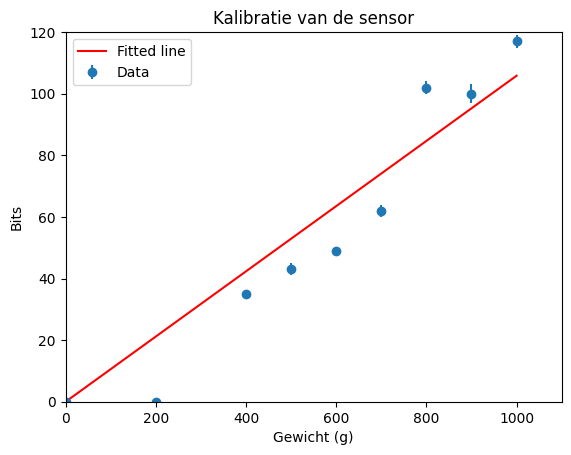

In [2]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

#curve_fit gebruiken om een lijn te fitten
from scipy.optimize import curve_fit
def line(x, a):
    return a * x

popt, pcov = curve_fit(line, gewichten, bits)
a = popt[0]
print(f'Fitted line: y = {a:.2f}x')


# Plot de data
plt.errorbar(gewichten, bits, yerr=bit_err, fmt='o', label='Data')
# Plot de fitted line
x_fit = np.linspace(min(gewichten), max(gewichten), 100)
y_fit = line(x_fit, *popt)
plt.plot(x_fit, y_fit, label='Fitted line', color='red')
plt.xlabel('Gewicht (g)')
plt.ylim(0, 120)
plt.xlim(0, 1100)
plt.ylabel('Bits')
plt.title('Kalibratie van de sensor')
plt.legend()
plt.show()


## *Opdracht 7*: Iteratie nodig?

De sensor is geschikt voor de door ons gekozen toepassing, we hebben geen extra metingen nodig.

## *Opdracht 8*: Conclusie, leerdoel

Met deze metingen is er achter gekomen dat deze sensor voldoet aan de gestelde criteria, het detecteren van een hoofd op kussen. De sensor detecteerd verschillende massa, en geeft daarvoor verschillende waardes.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
<div style="display: flex; gap: 20px;">
    <img src="fotomeetopstelling.png" width="300">
</div>

Deze foto laat de opstelling zien.

<div style="display: flex; gap: 20px;">
    <img src="Meetopstelling.png" width="300">
</div>

Deze foto laat zien hoe een meting wordt uitgevoerd

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.

<div style="display: flex; gap: 20px;">
    <img src="schets-circuit.png" width="300">
    <img src="schematische schets meetopstelling.png" width="300">
</div>

In deze foto is een schets te zien van het gebruikte circuit.

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Thermometer | is mijn eten te warm | moet kunnen meten tussen 40 en 80 graden C, met een onzekerheid van 5 graden C, moet een melding geven bij een temperatuur van meer dan 60 graden C. |
|Thermometer | oververhit een auto | moet aan kunnen geven dat iets warmer is dan 100 - 140 graden C, met een onzekerheid van 5 graden C, moet een melding geven bij een temperatuur van meer dan 120 graden C. |
|Thermometer | warmte schakelaar | moet verschil kunnen meten tussen 23 en 30 graden C, met een onzekerheid van 1 graden C, moet een stroomlaten lopen.|
|Lichtmeter | zonne meter voor planten | Criteria omschrijving |
|Lichtmeter | kan ik sterre zien | Criteria omschrijving  |
|Lichtmeter | licht dat aan gaat bij donker | kan het verschil meten tussen 0 en 1300 lux, met een onzekerheid van 50 lux, doet een lamp als er een kleinere lux is dan 1000 |
|krachtmeter | weegschaal | Criteria omschrijving |
|krachtmeter | schud me hand te hard | Criteria omschrijving |
|krachtmeter | uitbed, licht aan | Moet het verschill kunnen meten tussen 0kg 6kg met een onzekerheid van 1 kg, doet het licht uit als er meer dan 4.5 kg op zit.|

Groep 24 heeft gekozen voor de krachtsensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

## *Opdracht 6*: Meten en fitten, Leerdoel


In [3]:
# Zet hier jouw data in een voor jou handig formaat
gewichten = (0, 200, 400, 600, 800, 1000, 500, 700, 900) #g
bits = (0, 10, 35, 49, 102, 117, 43, 62, 100) #bits
bit_err = (0, 1, 1, 1, 2, 2, 2, 2, 3) #bits

Fitted line: y = 0.11x


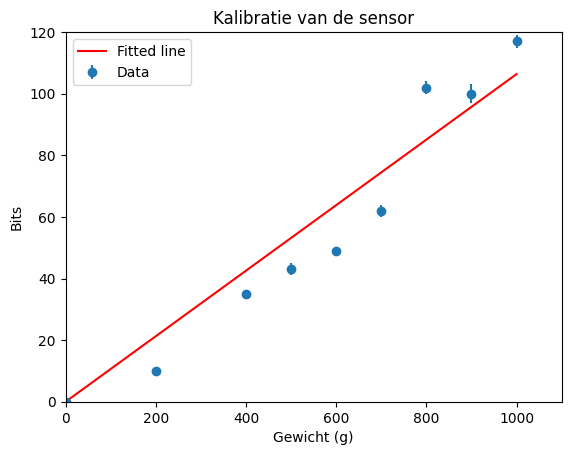

In [4]:
# Plot hier de meting en fit een lijn door de metingen.
# Maak gebruik van wat je geleerd hebt bij het practicum.
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

#curve_fit gebruiken om een lijn te fitten
from scipy.optimize import curve_fit
def line(x, a):
    return a * x

popt, pcov = curve_fit(line, gewichten, bits)
a = popt[0]
print(f'Fitted line: y = {a:.2f}x')


# Plot de data
plt.errorbar(gewichten, bits, yerr=bit_err, fmt='o', label='Data')
# Plot de fitted line
x_fit = np.linspace(min(gewichten), max(gewichten), 100)
y_fit = line(x_fit, *popt)
plt.plot(x_fit, y_fit, label='Fitted line', color='red')
plt.xlabel('Gewicht (g)')
plt.ylim(0, 120)
plt.xlim(0, 1100)
plt.ylabel('Bits')
plt.title('Kalibratie van de sensor')
plt.legend()
plt.show()


## *Opdracht 8*: Conclusie, leerdoel

Met deze metingen is er achter gekomen dat deze sensor voldoet aan de gestelde criteria, het detecteren van een hoofd op kussen. De sensor detecteerd verschillende massa, en geeft daarvoor verschillende waardes.